## People per dwelling

In [16]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import pathlib
from datetime import datetime

from scipy.optimize import curve_fit
import natural_cubic_spline_stack_overflow_kopi as ncs # taken from stack overflow

In [17]:
people_per_dwelling_data = pd.read_excel("people_per_dwelling_1986-2025.xlsx",skiprows=2)

people_per_dwelling_data.head()

PPD = people_per_dwelling_data[["Year","PPD"]]

PPD.head()

,Year,PPD
0,1986.0,2.300590
1,1987.0,2.280865
2,1988.0,2.265565
3,1989.0,2.246754
4,1990.0,2.232401


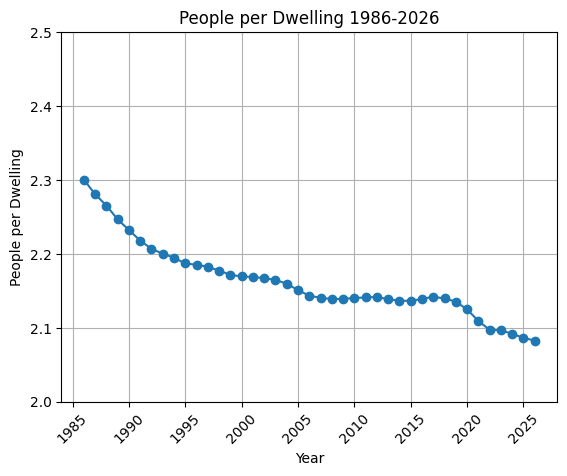

In [18]:
fig,ax = plt.subplots()
ax.plot(PPD["Year"], PPD["PPD"], marker='o')
ax.set_xlabel("Year")
ax.set_ylabel("People per Dwelling")
ax.set_title("People per Dwelling 1986-2026")
plt.xticks(rotation=45)
plt.grid()
ax.set_ylim(2, 2.5)   # show y-axis range 1.8 - 3
plt.show()

In [26]:
years = PPD["Year"].to_numpy()
values = PPD["PPD"].to_numpy()

print(type(values))

# Option A: with numpy.column_stack (recommended)
PPD_array = np.column_stack((years, values))

# Option B: with zip (keeps mixed dtypes)
#PPD_array = np.array(list(zip(years, values)))

print(PPD_array.shape)
print(PPD_array)

PPD_array = PPD_array[0:].astype(float)
print(type(PPD_array[0,0]))

#array with only first 41 elements
PPD_array = PPD_array[:41]
print(PPD_array)

<class 'numpy.ndarray'>
(328, 2)
[[1986.            2.3005904 ]
 [1987.            2.28086528]
 [1988.            2.26556504]
 [1989.            2.24675352]
 [1990.            2.23240075]
 [1991.            2.21814944]
 [1992.            2.20691056]
 [1993.            2.20039387]
 [1994.            2.19493079]
 [1995.            2.18716586]
 [1996.            2.18543575]
 [1997.            2.1826305 ]
 [1998.            2.17749774]
 [1999.            2.17170412]
 [2000.            2.16959964]
 [2001.            2.16876728]
 [2002.            2.16734243]
 [2003.            2.16493246]
 [2004.            2.15974296]
 [2005.            2.15111862]
 [2006.            2.14355198]
 [2007.            2.1406907 ]
 [2008.            2.139076  ]
 [2009.            2.13915893]
 [2010.            2.14053999]
 [2011.            2.14111626]
 [2012.            2.14189338]
 [2013.            2.13872094]
 [2014.            2.13695532]
 [2015.            2.13643629]
 [2016.            2.13915734]
 [2017

In [27]:
predictor_years = np.arange(1600, 2101)


In [28]:
def logistic(x:np.ndarray,ti:float,tau:float,C0:float,C1:float) -> np.ndarray:
    """
    General logistic function.
    Arguments:
    - x: np.ndarray of observation points (time)
    - ti: inflection time
    - tau: transition time coefficient
    - C0: start value
    - C1: end value

    Returns:
    - np.ndarray with len(x) number of points
    """
    return (C1 - C0)/(1 + np.exp(-(x - ti) / tau)) + C0

In [29]:
plt.clf()
inputs = PPD_array[:, 0]  # years
output = PPD_array[:, 1]  # population
pred_inputs = predictor_years

popt, pcov = curve_fit(logistic, inputs, output, p0=[1850, 40, 5, 2])
pred_outputs = logistic(pred_inputs, *popt)
print(f'The optimal choice of parameters for the logistic function, given the sample data, is {popt} (ti, tau, C0, C1).')

fig=plt.figure(figsize=(12, 6))
plt.plot(pred_inputs, pred_outputs, label='Logistic Fit', color='saddlebrown')
plt.scatter(inputs, output, label='Data Points', color='royalblue')
plt.title('PPD Prediction using Logistic Function')
plt.xlabel('Year')
plt.ylabel('People per Dwelling')
plt.legend()
plt.grid()
plt.show()

RuntimeError: Optimal parameters not found: Number of calls to function has reached maxfev = 1000.

<Figure size 640x480 with 0 Axes>

Estimated parameters:
ti (inflection year) = 1919.36
tau (transition speed) = 25.99
C0 (modern equilibrium) = 2.052
C1 (historical level, fixed) = 5.0


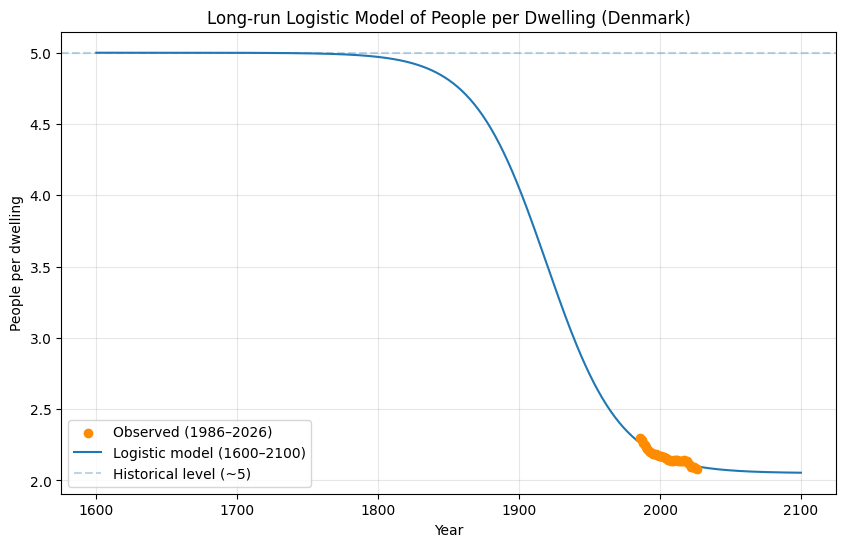

In [34]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ----------------------------
# 1. Your existing data setup
# ----------------------------

years = PPD["Year"].to_numpy()
values = PPD["PPD"].to_numpy()

PPD_array = np.column_stack((years, values)).astype(float)

# Keep first 41 observations (1986–2026)
PPD_array = PPD_array[:41]

x_data = PPD_array[:, 0]
y_data = PPD_array[:, 1]

# ----------------------------
# 2. Logistic function
# ----------------------------

def logistic(x: np.ndarray, ti: float, tau: float, C0: float, C1: float) -> np.ndarray:
    return (C1 - C0) / (1 + np.exp((x - ti) / tau)) + C0
    return (C1 - C0) / (1 + np.exp(-(x - ti) / tau)) + C0

# ----------------------------
# 3. Fix historical upper level
# ----------------------------

C1_fixed = 5.0  # historical people per dwelling

# Wrapper so we only estimate ti, tau, C0
def logistic_fixed(x, ti, tau, C0):
    return logistic(x, ti, tau, C0, C1_fixed)

# ----------------------------
# 4. Add historical anchor points
# ----------------------------
# These stabilize the long-run shape

anchor_years = np.array([1700, 1800, 1850])
anchor_values = np.array([5.0, 5.0, 4.8])  # slight decline by 1850 optional

x_aug = np.concatenate([x_data, anchor_years])
y_aug = np.concatenate([y_data, anchor_values])

# ----------------------------
# 5. Fit nonlinear regression
# ----------------------------

# Good starting guesses matter!
initial_guess = [1920, 40, 2.1]  # ti, tau, C0

params, covariance = curve_fit(
    logistic_fixed,
    x_aug,
    y_aug,
    p0=initial_guess,
    bounds=([1700, 5, 1.5], [2000, 200, 3])
)

ti_hat, tau_hat, C0_hat = params

print("Estimated parameters:")
print(f"ti (inflection year) = {ti_hat:.2f}")
print(f"tau (transition speed) = {tau_hat:.2f}")
print(f"C0 (modern equilibrium) = {C0_hat:.3f}")
print(f"C1 (historical level, fixed) = {C1_fixed}")

# ----------------------------
# 6. Predict 1600–2100
# ----------------------------

predictor_years = np.arange(1600, 2101)
predicted_ppd = logistic(predictor_years, ti_hat, tau_hat, C0_hat, C1_fixed)

# ----------------------------
# 7. Plot
# ----------------------------

plt.figure(figsize=(10, 6))

# Actual data
plt.scatter(x_data, y_data, label="Observed (1986–2026)", zorder=3, color='darkorange')

# Logistic fit
plt.plot(predictor_years, predicted_ppd, label="Logistic model (1600–2100)")

# Historical anchor line
plt.axhline(5, linestyle="--", alpha=0.3, label="Historical level (~5)")

plt.xlabel("Year")
plt.ylabel("People per dwelling")
plt.title("Long-run Logistic Model of People per Dwelling (Denmark)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [41]:
PPD_predicted_array = np.column_stack((predictor_years.astype(int), predicted_ppd))
print(PPD_predicted_array)

PPD_predicted_df_first = pd.DataFrame(PPD_predicted_array, columns=["Year", "Predicted_PPD"])
print(PPD_predicted_df_first)

PPD_predicted_df_first.to_excel("PPD_predicted_values_first.xlsx", index=False)

[[1.60000000e+03 4.99998644e+00]
 [1.60100000e+03 4.99998591e+00]
 [1.60200000e+03 4.99998535e+00]
 ...
 [2.09800000e+03 2.05474251e+00]
 [2.09900000e+03 2.05462763e+00]
 [2.10000000e+03 2.05451708e+00]]
       Year  Predicted_PPD
0    1600.0       4.999986
1    1601.0       4.999986
2    1602.0       4.999985
3    1603.0       4.999985
4    1604.0       4.999984
..      ...            ...
496  2096.0       2.054986
497  2097.0       2.054862
498  2098.0       2.054743
499  2099.0       2.054628
500  2100.0       2.054517

[501 rows x 2 columns]
